# Week 4 — Simulation modeling

Companion notebook of the fourth lecture. Weeks 2 and 3 fitted *solvable* models to data. Many real systems have no formula to fit or solve, so this week we make the **computer run the world for us**: Monte Carlo for areas and probabilities, the inverse-CDF trick for sampling any distribution, event simulation of a queue, stochastic population growth, an inventory decision, a traffic cellular automaton, and the **2024 MCM B** case (finding a lost submersible by Monte Carlo search).

**How to run**: Anaconda locally (`jupyter lab`), or Colab/Binder from the [course repository](https://github.com/liwt31/MathModel). Run cells in order with `Shift+Enter`.

**Note.** The exercises here and on the slides are **practice for yourself** — they are **not** the graded assignments. Problem sets are released separately on Blackboard, with due dates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:                                  # optional style file, ships with the course
    plt.style.use("mm.mplstyle")
except OSError:
    pass
rng = np.random.default_rng(42)       # one seeded generator for the whole notebook

## 1. Monte Carlo for a deterministic problem: the area under a curve

To find $A$, the area under $y = f(x)$ on $[a, b]$ with $0 \le f(x) \le M$: throw darts uniformly into the rectangle $[a,b]\times[0,M]$ and count the fraction that lands under the curve.
$$A \approx \frac{\text{hits}}{n}\,M(b-a).$$
The answer is **random**, so it has error — and the error shrinks like $1/\sqrt{n}$, whatever the dimension. That rate is the price of simulation and the reason Monte Carlo scales to problems with hundreds of inputs.

In [2]:
def f(x):
    return np.cos(x)

a, b, M = -np.pi/2, np.pi/2, 1.0      # exact area = 2
n = 100_000
x = rng.uniform(a, b, n)
y = rng.uniform(0, M, n)
hits = (y <= f(x)).sum()
area = hits / n * M * (b - a)
print(f"estimate = {area:.4f},  exact = 2")

estimate = 2.0044,  exact = 2


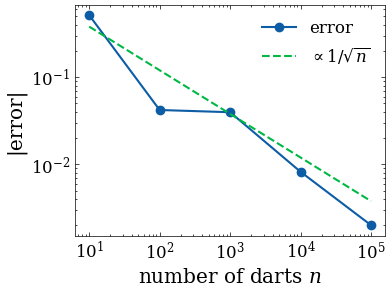

In [3]:
ns = 10 ** np.arange(1, 6)
est = []
for n in ns:
    x = rng.uniform(a, b, n)
    y = rng.uniform(0, M, n)
    est.append((y <= f(x)).mean() * M * (b - a))

plt.loglog(ns, np.abs(np.array(est) - 2), "o-", label="error")
plt.loglog(ns, 1.2 / np.sqrt(ns), "--", label=r"$\propto 1/\sqrt{n}$")
plt.xlabel("number of darts $n$"); plt.ylabel("|error|"); plt.legend(frameon=False)
plt.show()

The same dart-throwing gives $\pi$: a quarter circle of radius 1 inside the unit square has area $\pi/4$, so
$$\hat\pi = 4 \times \frac{\text{hits}}{n}.$$

pi_hat = 3.14108


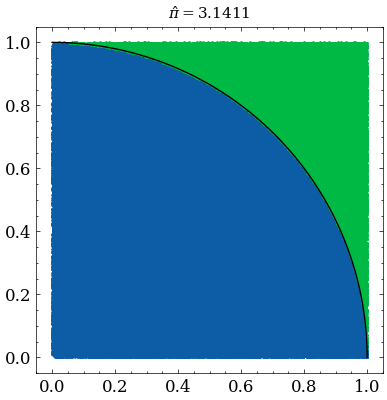

In [4]:
n = 200_000
pts = rng.uniform(0, 1, (n, 2))
inside = (pts**2).sum(axis=1) <= 1
print(f"pi_hat = {4 * inside.mean():.5f}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(pts[inside, 0], pts[inside, 1], s=1, color="C0")
ax.scatter(pts[~inside, 0], pts[~inside, 1], s=1, color="C1")
th = np.linspace(0, np.pi/2, 100)
ax.plot(np.cos(th), np.sin(th), color="k", lw=1)
ax.set_aspect("equal"); ax.set_title(f"$\\hat\\pi = {4 * inside.mean():.4f}$", fontsize=11)
plt.show()

## 2. Simulating probabilistic behavior: coin and die

A uniform random number $X \in [0,1]$ plus a **threshold** simulates any event with a known probability: heads when $X \le 0.5$, tails otherwise. An unfair die just needs the intervals to match the target probabilities.

P(head) simulated = 0.4989   (exact 0.5)


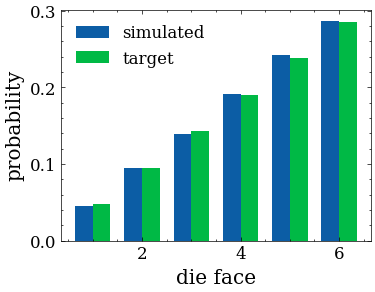

In [5]:
flips = rng.uniform(0, 1, 10_000)
heads = (flips <= 0.5).mean()
print(f"P(head) simulated = {heads:.4f}   (exact 0.5)")

# an unfair die with P(j) = j/21  (j = 1..6)
p = np.arange(1, 7) / 21
edges = np.cumsum(p)                       # interval boundaries
rolls = rng.uniform(0, 1, 20_000)
faces = np.searchsorted(edges, rolls) + 1
emp = np.bincount(faces, minlength=7)[1:] / len(rolls)

x = np.arange(1, 7)
plt.bar(x - 0.18, emp, width=0.36, label="simulated")
plt.bar(x + 0.18, p, width=0.36, label="target")
plt.xlabel("die face"); plt.ylabel("probability"); plt.legend(frameon=False)
plt.show()

## 3. The inverse-CDF trick: sampling any distribution

Every distribution has a **cumulative distribution function** $F(x) = P(X \le x)$, running from $0$ to $1$. The key fact: if $X$ follows density $f$, then $F(X)$ is **uniform on $[0,1]$**. Reversing gives the recipe — draw $R$ uniform on $[0,1]$, return $X = F^{-1}(R)$.

For the **exponential** distribution, $f(t) = \lambda e^{-\lambda t}$ (the classic model of the time *between* random arrivals, mean $1/\lambda$):
$$F(t) = 1 - e^{-\lambda t} \quad\Rightarrow\quad t = -\tfrac{1}{\lambda}\ln(1-R) \;\; (= -\tfrac{1}{\lambda}\ln R, \text{ same law}).$$

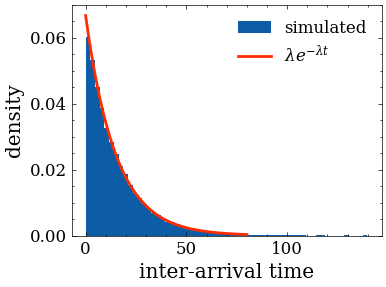

mean = 15.05 min   (target 15)


In [6]:
lam = 1 / 15                                # mean arrival gap of 15 minutes
t = -np.log(rng.uniform(0, 1, 20_000)) / lam

plt.hist(t, bins=60, density=True, label="simulated")
xs = np.linspace(0, 80, 200)
plt.plot(xs, lam * np.exp(-lam * xs), "C3", lw=2, label=r"$\lambda e^{-\lambda t}$")
plt.xlabel("inter-arrival time"); plt.ylabel("density"); plt.legend(frameon=False)
plt.show()
print(f"mean = {t.mean():.2f} min   (target 15)")

## 4. A queueing simulation: the harbor

One unloading berth; ships arrive with gaps uniform on $[15, 145]$ min and unload in $[45, 90]$ min. The textbook asks four questions about $100$ ships: average and maximum time in harbor, average and maximum waiting time, idle percentage, longest queue.

The engine is an **event loop**: pop the next event (arrival or departure) from a time-ordered heap; on arrival, start unloading if the berth is free, otherwise join the queue; on departure, free the berth and start the next ship's unloading.

In [7]:
n_ships = 100
arrival_intervals = rng.uniform(15, 145, n_ships)
unloading_times = rng.uniform(45, 90, n_ships)
arrival_times = np.cumsum(arrival_intervals)

import heapq
from collections import deque

events = [(t, "arrival", i) for i, t in enumerate(arrival_times)]
heapq.heapify(events)
queue = deque()
max_length = 0
staying_times = np.zeros(n_ships)
waiting_times = np.zeros(n_ships)
berth_busy = False
last_idle_start = 0.0
total_idle = 0.0

while events:
    t, kind, ship = heapq.heappop(events)
    if kind == "arrival":
        queue.append((ship, t))
        max_length = max(max_length, len(queue))
        if not berth_busy:
            berth_busy = True
            s, t0 = queue.popleft()
            waiting_times[s] = t - t0
            heapq.heappush(events, (t + unloading_times[s], "departure", s))
            total_idle += t - last_idle_start
    else:
        staying_times[ship] = t - arrival_times[ship]
        if queue:
            s, t0 = queue.popleft()
            waiting_times[s] = t - t0
            heapq.heappush(events, (t + unloading_times[s], "departure", s))
        else:
            berth_busy = False
            last_idle_start = t

t_end = max(arrival_times[-1] + unloading_times[-1], max(staying_times + arrival_times))
print(f"avg staying   = {staying_times.mean():6.1f} min   max = {staying_times.max():6.1f}")
print(f"avg waiting   = {waiting_times.mean():6.1f} min   max = {waiting_times.max():6.1f}")
print(f"berth idle    = {100 * total_idle / t_end:6.1f} %")
print(f"longest queue = {max_length}")

avg staying   =  116.1 min   max =  251.7
avg waiting   =   45.8 min   max =  168.2
berth idle    =   13.0 %
longest queue = 3


Both histograms are the point of the simulation. The **mean** alone hides the bad days; the tail of the waiting-time histogram is what the harbor manager worries about. The first waiting-time bin is unusually tall because many ships arrive at an idle berth and wait $0$ minutes.

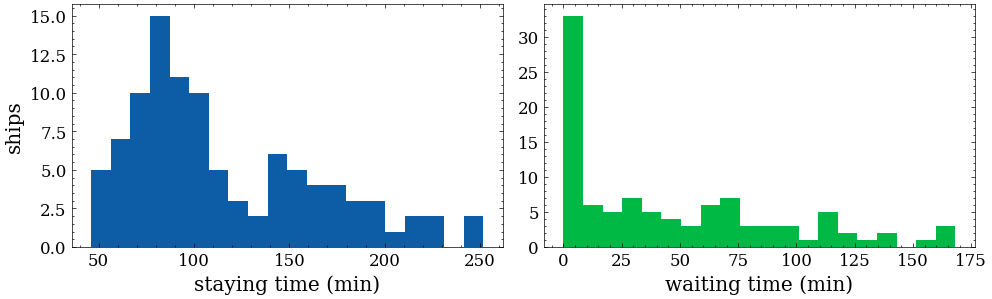

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(staying_times, bins=20)
axes[0].set_xlabel("staying time (min)"); axes[0].set_ylabel("ships")
axes[1].hist(waiting_times, bins=20, color="C1")
axes[1].set_xlabel("waiting time (min)")
fig.tight_layout(); plt.show()

**Changing the input distributions changes almost nothing in the code.** Deltas (deterministic times) and geometric gaps (a discrete-time queue) drop straight in — this is where simulation beats analysis: each "what if" is one line.

The textbook's Markov-chain analysis of a queue predicts a **geometric distribution** $P_N = (1-\rho)\rho^N$ for queue length and waiting time in steady state, with $\rho = \lambda/\mu < 1$ the traffic intensity (mean service over mean gap). The harbor's simulated waiting times, binned in $10$-minute slots, follow the prediction:

rho = mean service / mean gap = 0.82


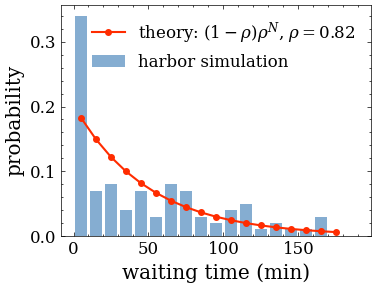

In [9]:
rho = waiting_times[waiting_times > 0].mean() / arrival_intervals.mean()
print(f"rho = mean service / mean gap = {rho:.2f}")
edges = np.append(0, np.arange(10, 200, 10))
emp = np.histogram(waiting_times, bins=edges)[0] / n_ships
centers = (edges[:-1] + edges[1:]) / 2
plt.bar(centers, emp, width=8, alpha=0.5, label="harbor simulation")
kk = np.arange(0, 18)
plt.plot(10 * kk + 5, (1 - rho) * rho**kk, "o-", color="C3", ms=4,
         label=rf"theory: $(1-\rho)\rho^N$, $\rho = {rho:.2f}$")
plt.xlabel("waiting time (min)"); plt.ylabel("probability")
plt.legend(frameon=False); plt.show()

## 5. The barber shop: recursion instead of an event heap

One barber; customers arrive with exponential gaps of mean $15$ min (so $p_i = -15\ln R$) and haircuts take $10 + 5R$ min, uniform on $[10, 15]$. With arrival times $T_i$, service starts $S_i$ and service lengths $L_i$,
$$S_{i+1} = \max\big(T_{i+1},\; S_i + L_i\big),$$
because the next customer starts when **both** they and the barber are ready. This single recursion replaces the whole event loop, and the deck's five-customer hand simulation is exactly this formula with the textbook's random numbers.

In [10]:
R_arr = [0.0589, 0.4799, 0.6139, 0.9341]           # textbook's draws for p_1..p_4
R_srv = [0.6733, 0.9486, 0.5933, 0.1782, 0.3473]   # and for L_1..L_5
p = [-15 * np.log(r) for r in R_arr]
L = [10 + 5 * r for r in R_srv]
T = np.concatenate([[0], np.cumsum(p)])            # T_1..T_5
S = np.zeros(5)
for i in range(1, 5):
    S[i] = max(T[i], S[i-1] + L[i-1])
dep = S + L                                        # departure times
W = S - T                                          # waiting times
print("arrivals T :", np.round(T, 2))
print("service S  :", np.round(S, 2))
print("departures :", np.round(dep, 2))
print("waiting W  :", np.round(W, 2))
print(f"avg waiting = {W.mean():.2f} min   (deck: 6.47)")
print(f"berth utilization = {np.sum(L) / dep[-1]:.3f}   (deck: 0.686)")

arrivals T : [ 0.   42.48 53.49 60.81 61.83]
service S  : [ 0.   42.48 57.22 70.19 81.08]
departures : [13.37 57.22 70.19 81.08 92.82]
waiting W  : [ 0.    0.    3.73  9.38 19.25]
avg waiting = 6.47 min   (deck: 6.47)
berth utilization = 0.686   (deck: 0.686)


Larger runs just call the recursion in a loop. The three indexes are themselves **random variables** — rerun with a different seed and they move — so serious use repeats the whole simulation many times and reports means and spreads, never a single number.

In [11]:
def barber(n, rng):
    T = np.concatenate([[0], np.cumsum(-15 * np.log(rng.uniform(size=n - 1)))])
    L = rng.uniform(10, 15, n)
    S = np.zeros(n)
    for i in range(1, n):
        S[i] = max(T[i], S[i-1] + L[i-1])
    return (S - T).mean(), L.sum() / (S[-1] + L[-1])

rng2 = np.random.default_rng(7)
reps = [barber(500, rng2) for _ in range(200)]
w = np.array([r[0] for r in reps]); u = np.array([r[1] for r in reps])
print(f"avg waiting over 200 runs   = {w.mean():.2f} ± {w.std():.2f} min")
print(f"utilization over 200 runs   = {u.mean():.3f} ± {u.std():.3f}")

avg waiting over 200 runs   = 31.50 ± 11.94 min
utilization over 200 runs   = 0.838 ± 0.038


## 6. When noise matters: stochastic population growth

Week 2's exponential model $\Delta n = b\,n\,\Delta t$ is deterministic. Make births **random events** — in each small $\Delta t$ every individual gives birth with probability $b\,\Delta t$ — and each run tells a different story. The mean still tracks $e^{bt}N_0$, but the spread grows with time, and the **coefficient of variation** $\sigma/\text{mean}$ follows $\sqrt{(1-e^{-bt})/N_0}$: small populations live dangerously.

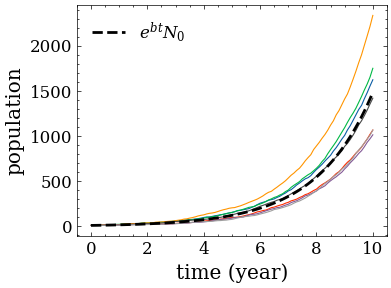

In [12]:
b, n0, n_years, dt = 0.5, 10, 10, 0.1
steps = round(n_years / dt)

def one_trajectory(rng):
    n = n0
    traj = np.empty(steps + 1); traj[0] = n
    for i in range(steps):
        n += (rng.uniform(size=n) < b * dt).sum()
        traj[i + 1] = n
    return traj

t = np.arange(steps + 1) * dt
trajs = np.array([one_trajectory(rng) for _ in range(7)])
for tr in trajs:
    plt.plot(t, tr, lw=0.8)
plt.plot(t, n0 * np.exp(b * t), "k--", lw=2, label=r"$e^{bt}N_0$")
plt.xlabel("time (year)"); plt.ylabel("population"); plt.legend(frameon=False)
plt.show()

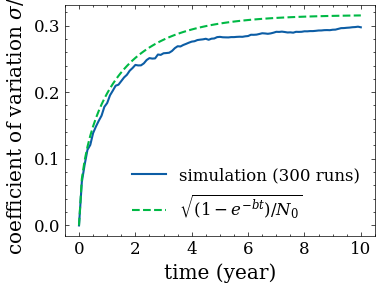

In [13]:
big = np.array([one_trajectory(rng) for _ in range(300)])
cv = big.std(axis=0) / big.mean(axis=0)
plt.plot(t, cv, label="simulation (300 runs)")
plt.plot(t, np.sqrt((1 - np.exp(-b * t)) / n0), "--", label=r"$\sqrt{(1-e^{-bt})/N_0}$")
plt.xlabel("time (year)"); plt.ylabel(r"coefficient of variation $\sigma/\mu$")
plt.legend(frameon=False); plt.show()

## 7. Simulation as a decision: the gas station

A station receives a delivery of `interval` days' worth of fuel each time; demand is normal around $1500$ units a day. Frequent deliveries cost fees; rare deliveries tie money up in storage. Total cost = delivery fees + storage cost. Simulate a year for each interval and pick the cheapest — the curve's minimum is the answer, and the classical EOQ formula $\sqrt{2K/(h\,d)}$ lands right next to it.

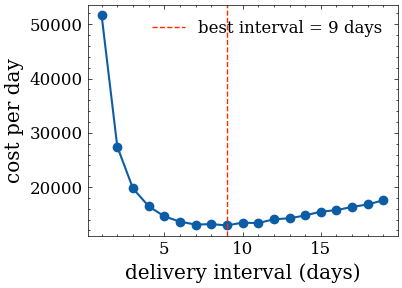

EOQ formula = 8.16 days


In [14]:
n_days = 365
demands = np.maximum(0, rng.normal(1500, 200, n_days))
delivery_cost, storage_cost = 50000, 1

def simulate(interval, demands):
    stock, cost = 0, 0.0
    for i, dem in enumerate(demands):
        if i % interval == 0:
            stock += 1500 * interval
            cost += delivery_cost
        stock = max(stock - dem, 0)
        cost += stock * storage_cost
    return cost / n_days

intervals = np.arange(1, 20)
costs = [simulate(k, demands) for k in intervals]
k_best = intervals[int(np.argmin(costs))]
plt.plot(intervals, costs, "o-")
plt.axvline(k_best, color="C3", ls="--", lw=1, label=f"best interval = {k_best} days")
plt.xlabel("delivery interval (days)"); plt.ylabel("cost per day")
plt.legend(frameon=False); plt.show()
print(f"EOQ formula = {np.sqrt(2 * delivery_cost / storage_cost / 1500):.2f} days")

## 8. A cellular automaton: traffic

A cellular automaton replaces equations with **local rules** applied to a grid. The Nagel–Schreckberg model of a one-lane road: each car has speed $0..5$; speed up by 1 if the gap allows, slow down to the gap otherwise, with $10\,\%$ random braking; move. Fifteen lines of NumPy produce jams out of nowhere — no formula anywhere.

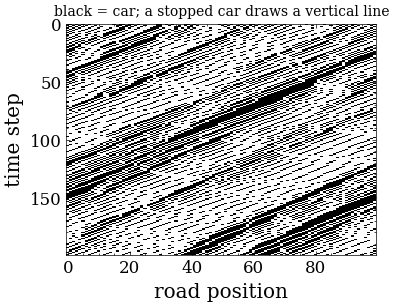

In [15]:
road, cars, steps, p_brake = 100, 35, 200, 0.1
positions = np.sort(rng.choice(road, cars, replace=False))
speeds = np.zeros(cars, dtype=int)
history = np.zeros((steps, road))

for s in range(steps):
    gaps = np.roll(positions, -1) - positions
    gaps = (gaps - 1) % road
    speeds = np.minimum(speeds + 1, 5)
    speeds = np.minimum(speeds, gaps)
    braking = rng.uniform(size=cars) < p_brake
    speeds = np.maximum(speeds - braking, 0)
    positions = (positions + speeds) % road
    history[s] = np.bincount(positions, minlength=road)

plt.imshow(history, aspect="auto", cmap="Greys", interpolation="nearest")
plt.xlabel("road position"); plt.ylabel("time step")
plt.title("black = car; a stopped car draws a vertical line", fontsize=10)
plt.show()

## 9. Case study: finding the lost submersible (2024 MCM B)

The **2024 MCM Problem B** sends a tourist submersible into the Ionian Sea that loses contact with its host ship. Team **2411570** (Outstanding) builds the position prediction from ocean currents, waves, wind and drag, then faces the Week-4 question with Monte Carlo. The inputs are uncertain, so they **make the uncertain inputs random**: wave velocity, current velocity and wind velocity become random numbers in $[-1,1]$, $[-1,1]$ and $[-0.87, 1]$, plus a white-noise signal term, and each random draw produces one candidate resting place of the submersible.

d_max = 4302 m   (diameter of the search circle)


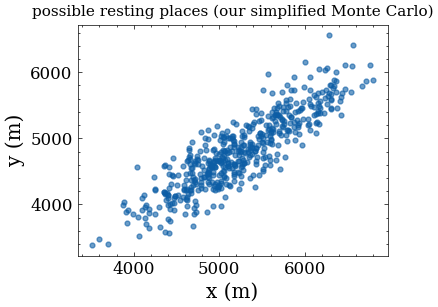

In [16]:
n_sims = 500
v_wave = rng.uniform(-1, 1, n_sims)          # the paper's randomized inputs
v_curr = rng.uniform(-1, 1, n_sims)
v_wind = rng.uniform(-0.87, 1, n_sims)
noise_x = rng.normal(0, 0.15, n_sims)        # their white-noise signal term, scaled
noise_y = rng.normal(0, 0.15, n_sims)

# simplified drift kinematics: displacement ~ weighted sum of the random drivers
x = 5200 + 900 * v_curr + 500 * v_wind + 300 * v_wave + 1500 * noise_x
y = 4800 + 800 * v_curr + 400 * v_wave + 300 * v_wind + 1200 * noise_y

plt.scatter(x, y, s=12, alpha=0.6)
d_max = np.max(np.hypot(x - x[:, None], y - y[:, None]))
print(f"d_max = {d_max:.0f} m   (diameter of the search circle)")
plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.title("possible resting places (our simplified Monte Carlo)", fontsize=11)
plt.show()

The cloud is **concentrated in one direction**, so the search starts from a point of high probability and spirals outward. The sensor hangs at height $h$ above the seabed with half-angle $\theta$, so one pass sees a disc of radius $2h\tan\theta$; circling at speed $v_{rc}$ sweeps area at rate $s = 2h\tan\theta\, v_{rc}$ per unit time (their Equation 11). Each full circle moves the spiral out by $2h\tan\theta$, so consecutive rings just touch.

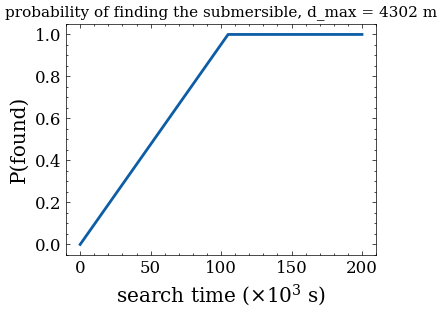

time to P = 0.9: about 26.2 hours


In [17]:
h, theta = 40, np.radians(30)
v_rc, v_rt = 3.0, 1.0                        # circle and radial speeds (m/s)
r_foot = 2 * h * np.tan(theta)               # sensor footprint radius
s_rate = 2 * h * np.tan(theta) * v_rc        # swept area per unit time (their Eq. 11)

t = np.linspace(0, 200_000, 4000)
S_search = s_rate * t
S_total = np.pi * (d_max / 2) ** 2
P = np.minimum(S_search / S_total, 1.0)      # their Eq. 15: P = S'/S

plt.plot(t / 1000, P, lw=2)
plt.xlabel(r"search time ($\times 10^3$ s)"); plt.ylabel("P(found)")
plt.title(f"probability of finding the submersible, d_max = {d_max:.0f} m", fontsize=11)
plt.show()
t90 = t[np.argmax(P >= 0.9)] / 3600
print(f"time to P = 0.9: about {t90:.1f} hours")

The paper's Figure 12 shows the same rising curve for two scenarios (sunk to the seabed, or hanging at a neutral-buoyancy point), with small notches where the device translates radially between rings. The Monte Carlo logic is the whole story: **random inputs → a cloud of possible outcomes → a search plan sized to the cloud.**

## Practice exercises

**These are practice for yourself — they are not the graded assignments.** Problem sets are released separately on Blackboard, with due dates.

1. **Area by darts.** Estimate the area under $y = e^{-x}$ on $[0, 2]$ with $n = 10^5$ darts; compare with the exact value $1 - e^{-2}$. Then plot the error against $n$ on log-log axes and check the $1/\sqrt{n}$ slope.
2. **Loaded die.** Simulate a die with $P(6) = 0.3$ and the remaining probability split equally among faces 1–5, using the interval assignment of Section 2. How many rolls until the empirical maximum deviation from the target is below $0.01$?
3. **Inverse CDF.** Derive the sampling formula for the **triangular** density on $[0,1]$ with peak at $1/2$, and verify your formula with a histogram.
4. **Two counters.** Add a second berth to the harbor simulation. How much do average waiting time and the longest queue drop? Is the second berth worth it if it costs $30\,\%$ more?
5. **Barber rush hour.** Change the barber's mean arrival gap to $12$ min. Does the waiting time grow linearly, or blow up? Relate what you see to $\rho = \lambda/\mu$ approaching $1$.
6. **Extinction risk.** In the stochastic population model, estimate by simulation the probability that the population has *doubled* by year 10 for $N_0 = 3$. Compare with the deterministic prediction.
7. **Search plan.** In the submersible case, how does the time to reach $P = 0.9$ change if the sensor half-angle $\theta$ doubles? What does that suggest about where to spend money, on a faster robot or a wider sensor?
